# Clinical Trial Enrichment Benchmark

Validates whether genetic evidence enriches progression through clinical
trial phases, using open data sources and compares with Citeline subset published by Minikel et al., 2024.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ct_validation import forest_plot, validate
from matplotlib.ticker import FuncFormatter
from tidepool import set_mpl_style

set_mpl_style()
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Inter", "Helvetica", "Arial", "DejaVu Sans"]

DATA = Path("../data")
GE_DIR = DATA / "genetic_evidence"
CT_DIR = DATA / "clinical_trials"

CLINICAL_TRIALS = CT_DIR / "aggregated" / "gene_indication_max_phase.parquet"
SIMILARITY = DATA / "mappings" / "efo_similarity_lookup_0.5.parquet"
GENE_UNIVERSE = DATA / "mappings" / "protein_coding_genes.txt"

GE_SOURCES = {
    "GWAS Catalog": GE_DIR / "gwas_catalog.parquet",
    "ClinVar": GE_DIR / "clinvar.parquet",
    "OpenTargets": GE_DIR / "opentargets.parquet",
    "OMIM": GE_DIR / "omim.parquet",
    "Genebass": GE_DIR / "genebass.parquet",
}
GE_COMBINED = GE_DIR / "aggregated" / "genetic_evidence.parquet"

MINIKEL_DIR = DATA / "minikel"

VALIDATE_KWARGS = dict(similarity_lookup=SIMILARITY, gene_universe=GENE_UNIVERSE)

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)
FIGS = OUTPUT / "figures"
FIGS.mkdir(exist_ok=True)

PHASE_ORDER = ["I→II", "II→III", "III→Approved", "I→Approved"]
CT_GD_SOURCES = ["ChEMBL", "DGIdb", "STITCH", "OpenTargets", "TrialPanorama"]
CT_DI_SOURCES = ["ChEMBL", "OpenTargets", "TrialPanorama"]

In [2]:
def run_multi(experiments: dict[str, tuple], label_col="experiment") -> pd.DataFrame:
    """Run validate() for multiple (targets, clinical_trials) pairs."""
    results = []
    for name, (ge, ct) in experiments.items():
        r = validate(clinical_trials=ct, targets=ge, **VALIDATE_KWARGS)
        r[label_col] = name
        results.append(r)
    return pd.concat(results, ignore_index=True)


def filter_ct_by(ct: pd.DataFrame, column: str, source: str) -> pd.DataFrame:
    """Filter CT to rows where column contains source, keep validate() schema."""
    return ct[ct[column].str.contains(source, na=False)][["gene", "efo_id", "max_phase"]]


def savefig(fig, name):
    """Save figure as both SVG and PNG."""
    fig.savefig(FIGS / f"{name}.svg", bbox_inches="tight")
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight", dpi=300)

## 1. Prepare Minikel (Citeline) data

Citeline phases (ccatnum): 1=Preclinical, 2=Phase I, ..., 5=Launched

Our phases (max_phase): 0=Preclinical, 1=Phase I, ..., 4=Approved

In [3]:
minikel_ct_raw = pd.read_parquet(MINIKEL_DIR / "minikel_pharmaprojects_efo.parquet")
minikel_ct = minikel_ct_raw[["gene", "efo_id", "ccatnum"]].copy()
minikel_ct["max_phase"] = minikel_ct["ccatnum"] - 1
minikel_ct = minikel_ct.drop(columns=["ccatnum"])
minikel_ct = minikel_ct[minikel_ct["gene"].notna() & minikel_ct["efo_id"].notna()]

minikel_ge = (
    pd.read_parquet(MINIKEL_DIR / "minikel_associations_efo.parquet")[["gene", "efo_id"]]
    .drop_duplicates()
    .dropna()
)

print(f"Minikel CT: {len(minikel_ct):,} pairs, {minikel_ct['gene'].nunique():,} genes")
print(f"Minikel GE: {len(minikel_ge):,} pairs, {minikel_ge['gene'].nunique():,} genes")

Minikel CT: 44,058 pairs, 2,462 genes
Minikel GE: 107,365 pairs, 12,523 genes


## 2. 2x2 comparison: Our vs Minikel (GE x CT)

|               | Citeline CT     | Our CT          |
|---------------|-----------------|-----------------|
| Minikel GE    | Replication     | Open CT quality |
| Our GE        | GE quality      | Headline        |

In [4]:
comparison = {
    "Minikel et al. GE × Citeline": (minikel_ge, minikel_ct),
    "Combined GE × Citeline": (GE_COMBINED, minikel_ct),
    "Minikel et al. GE × Combined CT": (minikel_ge, CLINICAL_TRIALS),
    "Combined GE × Combined CT": (GE_COMBINED, CLINICAL_TRIALS),
}
comparison_2x2 = run_multi(comparison)
comparison_2x2.to_csv(OUTPUT / "comparison_2x2.csv", index=False)

# Sanity check: compare our EFO replication against Minikel's published MESH results
minikel_published = pd.read_parquet(
    MINIKEL_DIR / "minikel_enrichment_results.parquet",
)
minikel_published = minikel_published[minikel_published["area"] == "all"]
our_replication = comparison_2x2[comparison_2x2["experiment"] == "Minikel et al. GE × Citeline"]

phase_map = {"I": "I→II", "II": "II→III", "III": "III→Approved", "I-Launch": "I→Approved"}
print(f"{'Phase':<15} {'Minikel (MESH)':>15} {'Ours (EFO)':>12}")
for _, row in minikel_published.iterrows():
    label = phase_map.get(row["phase"])
    if label is None:
        continue
    our = our_replication[our_replication["phase_label"] == label].iloc[0]
    print(f"{label:<15} {row['rs']:>15.3f} {our['rr']:>12.3f}")

Phase            Minikel (MESH)   Ours (EFO)
I→II                      1.076        1.115
II→III                    1.571        1.763
III→Approved              1.275        1.443
I→Approved                2.632        2.837


/tmp/ipykernel_3169262/2345553557.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


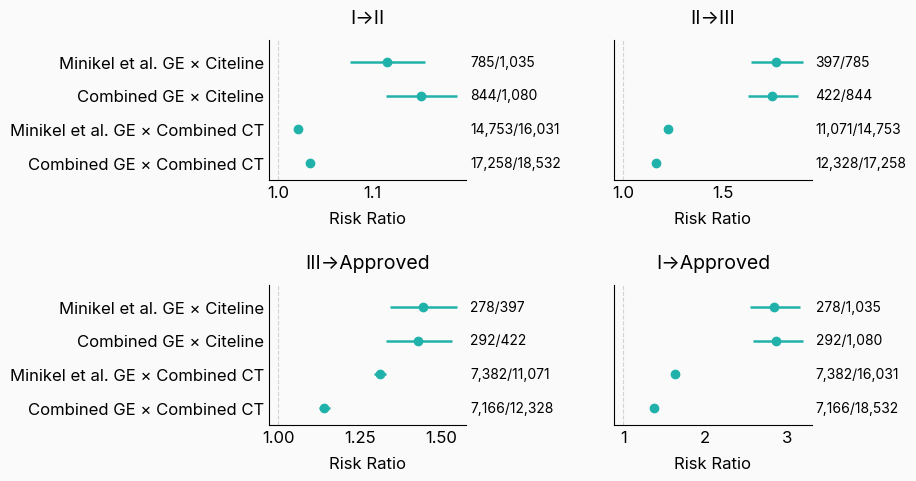

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5), gridspec_kw={"wspace": 0.75, "hspace": 0.75})
for ax, phase in zip(flat_ax := axes.flatten(), PHASE_ORDER):
    forest_plot(
        comparison_2x2,
        label_col="experiment",
        phase=phase,
        title=phase,
        ax=ax,
        sort_order=list(comparison.keys())[::-1],
    )
    if ax in (flat_ax[1], flat_ax[3]):
        ax.set_yticklabels([])
    ax.set_ylim(-0.5, ax.get_ylim()[1] + 0.5)
fig.tight_layout()
savefig(fig, "b_2x2_all_phases")

## 3. Per genetic evidence source

Each GE source separately, against both Citeline and Open CT.

In [6]:
ge_vs_our_ct = validate(
    clinical_trials=CLINICAL_TRIALS,
    targets=list(GE_SOURCES.values()),
    **VALIDATE_KWARGS,
)
for name, result in zip(GE_SOURCES, ge_vs_our_ct):
    result["source"] = name
    result["ct"] = "Open CT"

ge_vs_citeline = validate(
    clinical_trials=minikel_ct,
    targets=list(GE_SOURCES.values()),
    **VALIDATE_KWARGS,
)
for name, result in zip(GE_SOURCES, ge_vs_citeline):
    result["source"] = name
    result["ct"] = "Citeline CT"

ge_comparison = pd.concat([*ge_vs_our_ct, *ge_vs_citeline], ignore_index=True)
ge_comparison.to_csv(OUTPUT / "ge_source_comparison.csv", index=False)

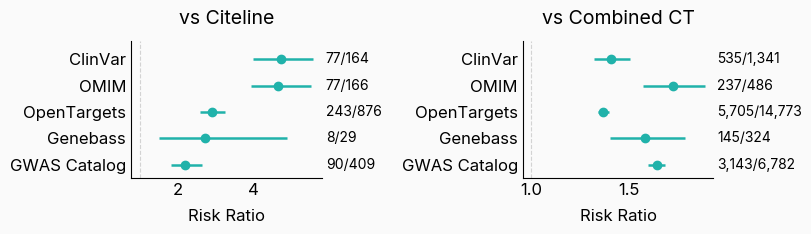

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.3, 2.5))
forest_plot(
    ge_comparison[ge_comparison["ct"] == "Citeline CT"],
    "source",
    "I→Approved",
    title="vs Citeline",
    ax=ax1,
)
order = [t.get_text() for t in ax1.get_yticklabels()]
forest_plot(
    ge_comparison[ge_comparison["ct"] == "Open CT"],
    "source",
    "I→Approved",
    title="vs Combined CT",
    ax=ax2,
    sort_order=order,
)
for ax in (ax1, ax2):
    ax.set_ylim(-0.5, ax.get_ylim()[1] + 0.5)
fig.tight_layout()
savefig(fig, "c_ge_sources")

## 4. Per clinical trial source

Gene-drug and drug-indication sources side by side.
Filtering on gene-drug source doesn't affect max_phase (comes from drug-indication).

In [8]:
ct_all = pd.read_parquet(CLINICAL_TRIALS)

gd_comparison = run_multi(
    {src: (GE_COMBINED, filter_ct_by(ct_all, "gene_drug_sources", src)) for src in CT_GD_SOURCES},
    label_col="source",
)
gd_comparison["ct_dimension"] = "gene_drug"

di_comparison = run_multi(
    {
        src: (GE_COMBINED, filter_ct_by(ct_all, "drug_indication_sources", src))
        for src in CT_DI_SOURCES
    },
    label_col="source",
)
di_comparison["ct_dimension"] = "drug_indication"

ct_comparison = pd.concat([gd_comparison, di_comparison], ignore_index=True)
ct_comparison.to_csv(OUTPUT / "ct_source_comparison.csv", index=False)

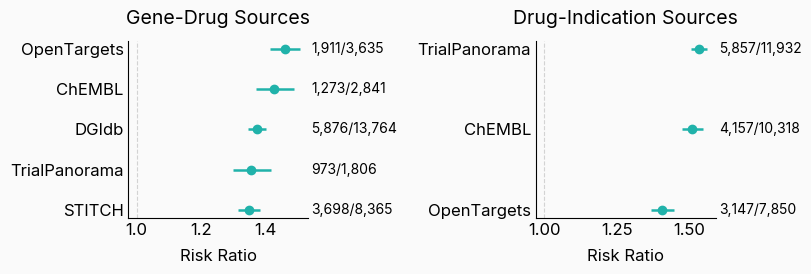

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.3, 2.9))
forest_plot(gd_comparison, "source", "I→Approved", title="Gene-Drug Sources", ax=ax1)
forest_plot(di_comparison, "source", "I→Approved", title="Drug-Indication Sources", ax=ax2)
fig.tight_layout()
savefig(fig, "e_ct_sources")

## 5. Coverage statistics

In [10]:
coverage_rows = []

# Minikel reference
coverage_rows.append(
    {
        "domain": "genetic_evidence",
        "source": "Minikel (Citeline)",
        "pairs": len(minikel_ge),
        "genes": minikel_ge["gene"].nunique(),
        "efo_ids": minikel_ge["efo_id"].nunique(),
    },
)
coverage_rows.append(
    {
        "domain": "clinical_trials",
        "source": "Minikel (Citeline)",
        "pairs": len(minikel_ct),
        "genes": minikel_ct["gene"].nunique(),
        "efo_ids": minikel_ct["efo_id"].nunique(),
    },
)

# GE sources
for name, path in [("Combined", GE_COMBINED), *GE_SOURCES.items()]:
    df = pd.read_parquet(path)
    coverage_rows.append(
        {
            "domain": "genetic_evidence",
            "source": name,
            "pairs": len(df),
            "genes": df["gene"].nunique(),
            "efo_ids": df["efo_id"].nunique(),
        },
    )

# CT sources
ct_all = pd.read_parquet(CLINICAL_TRIALS)
coverage_rows.append(
    {
        "domain": "clinical_trials",
        "source": "Combined",
        "pairs": len(ct_all),
        "genes": ct_all["gene"].nunique(),
        "efo_ids": ct_all["efo_id"].nunique(),
    },
)
for src in CT_GD_SOURCES:
    subset = filter_ct_by(ct_all, "gene_drug_sources", src)
    coverage_rows.append(
        {
            "domain": "ct_gene_drug",
            "source": src,
            "pairs": len(subset),
            "genes": subset["gene"].nunique(),
            "efo_ids": subset["efo_id"].nunique(),
        },
    )
for src in CT_DI_SOURCES:
    subset = filter_ct_by(ct_all, "drug_indication_sources", src)
    coverage_rows.append(
        {
            "domain": "ct_drug_indication",
            "source": src,
            "pairs": len(subset),
            "genes": subset["gene"].nunique(),
            "efo_ids": subset["efo_id"].nunique(),
        },
    )

coverage = pd.DataFrame(coverage_rows)
coverage.to_csv(OUTPUT / "coverage.csv", index=False)

In [11]:
def make_upset_df(
    df: pd.DataFrame,
    source_col: str,
    *,
    min_size: int = 0,
    n_intersections: int | None = None,
) -> pd.DataFrame:
    """Build intersection counts from '&'-delimited source column.

    Returns DataFrame with columns: combination (frozenset), count, sources (list of str),
    sorted by count descending, filtered by min_size.
    """
    all_sources = sorted({s for combo in df[source_col] for s in combo.split("&")})
    counts = df[source_col].value_counts()
    rows = []
    for i, (combo_str, count) in enumerate(counts.items()):
        members = frozenset(combo_str.split("&"))
        if count >= min_size and (n_intersections is None or i < n_intersections):
            rows.append(
                {"members": members, "count": count, **{s: s in members for s in all_sources}},
            )
    result = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    result.attrs["all_sources"] = all_sources
    return result


def _compact_num(x):
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f}M".replace(".0M", "M")
    if abs(x) >= 10e3:
        return f"{x / 1e3:.0f}K"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.1f}K".replace(".0K", "K")
    return f"{x:.0f}"


_compact_formatter = FuncFormatter(lambda x, _: _compact_num(x))


def plot_upset(
    upset_df: pd.DataFrame,
    title: str = "",
    figsize: tuple = (8.3, 4.2),
    dot_size: int = 80,
    wspace: int = 0.4,
):
    """Manual UpSet plot: top bars (intersection size) + dot matrix + left bars (set size)."""
    all_sources = upset_df.attrs["all_sources"]
    n_combos = len(upset_df)

    # Compute set sizes and sort sources by size (largest on top)
    set_sizes = {s: upset_df.loc[upset_df[s], "count"].sum() for s in all_sources}
    sources = sorted(all_sources, key=lambda s: set_sizes[s])
    n_sources = len(sources)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[1, 4],
        height_ratios=[7, n_sources],
        hspace=0.05,
        wspace=wspace,
    )

    ax_bars = fig.add_subplot(gs[0, 1])
    ax_matrix = fig.add_subplot(gs[1, 1], sharex=ax_bars)
    ax_setsize = fig.add_subplot(gs[1, 0])

    x = np.arange(n_combos)

    # Top: intersection size bars
    ax_bars.bar(x, upset_df["count"])
    for i, count in enumerate(upset_df["count"]):
        ax_bars.text(
            i,
            count + 0.01 * upset_df["count"].max(),
            _compact_num(count),
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax_bars.set_ylabel("Intersection Size")
    ax_bars.set_xlim(-0.5, n_combos - 0.5)
    ax_bars.tick_params(bottom=False, labelbottom=False)
    ax_bars.yaxis.set_major_formatter(_compact_formatter)
    if title:
        ax_bars.set_title(title)

    # Bottom-right: dot matrix
    for row_idx, source in enumerate(sources):
        y_pos = n_sources - 1 - row_idx
        for col_idx in range(n_combos):
            is_member = upset_df.iloc[col_idx][source]
            ax_matrix.scatter(
                col_idx,
                y_pos,
                s=dot_size,
                color="lightseagreen" if is_member else "lightgray",
                zorder=3,
            )

    for col_idx in range(n_combos):
        active = [n_sources - 1 - i for i, s in enumerate(sources) if upset_df.iloc[col_idx][s]]
        if len(active) > 1:
            ax_matrix.plot(
                [col_idx, col_idx],
                [min(active), max(active)],
                color="lightseagreen",
                linewidth=1.5,
                zorder=3,
            )

    y_positions = [n_sources - 1 - i for i in range(n_sources)]

    ax_matrix.set_xlim(-0.5, n_combos - 0.5)
    ax_matrix.set_ylim(-0.5, n_sources - 0.5)
    ax_matrix.tick_params(bottom=False, labelbottom=False)
    ax_matrix.grid(visible=False)
    ax_matrix.set_yticks(y_positions)
    ax_matrix.set_yticklabels(sources)
    ax_matrix.spines["bottom"].set_visible(False)
    ax_matrix.spines["left"].set_visible(False)

    # Bottom-left: set size bars (horizontal)
    sizes = [set_sizes[s] for s in sources]
    ax_setsize.barh(y_positions, sizes)
    for yp, size in zip(y_positions, sizes):
        ax_setsize.text(
            size + 0.03 * max(sizes),
            yp,
            f" {_compact_num(size)}",
            ha="right",
            va="center",
            fontsize=9,
        )
    ax_setsize.set_yticks(y_positions)
    ax_setsize.set_yticklabels([])
    ax_setsize.invert_xaxis()
    ax_setsize.spines["left"].set_visible(False)
    ax_setsize.spines["right"].set_visible(True)
    ax_setsize.set_xlabel("Set Size")
    ax_setsize.xaxis.set_major_formatter(_compact_formatter)
    ax_setsize.set_ylim(-0.5, n_sources - 0.5)

    return fig

### UpSet: Genetic evidence sources

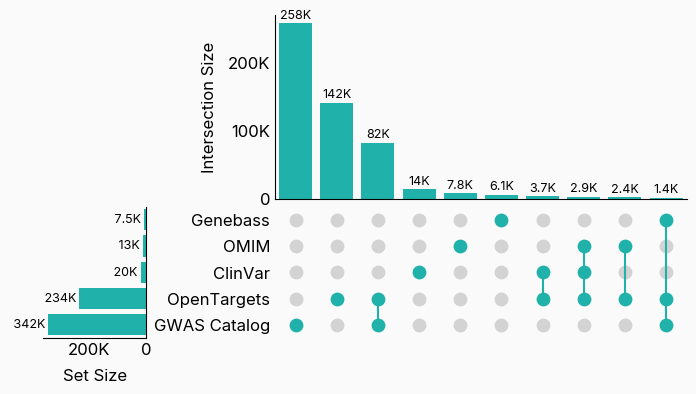

In [12]:
ge_all = pd.read_parquet(GE_COMBINED)
ge_upset = make_upset_df(ge_all, "source", n_intersections=10)
fig = plot_upset(ge_upset, wspace=0.5)
savefig(fig, "d1_ge_upset")

### UpSet: CT gene-drug sources

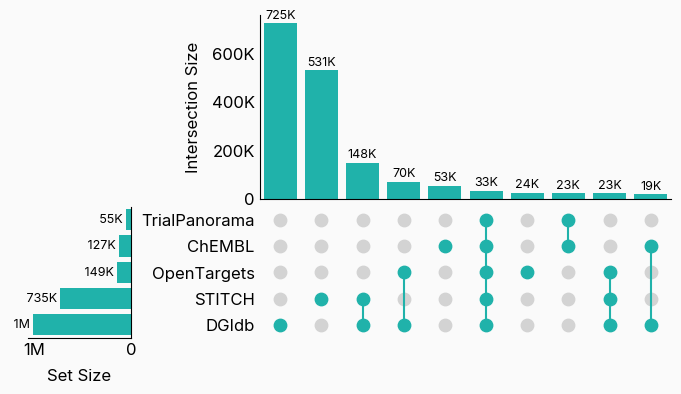

In [13]:
ct_all = pd.read_parquet(CLINICAL_TRIALS)
gd_upset = make_upset_df(ct_all, "gene_drug_sources", n_intersections=10)
fig = plot_upset(gd_upset, wspace=0.5)
savefig(fig, "d2_gd_upset")

### UpSet: CT drug-indication sources

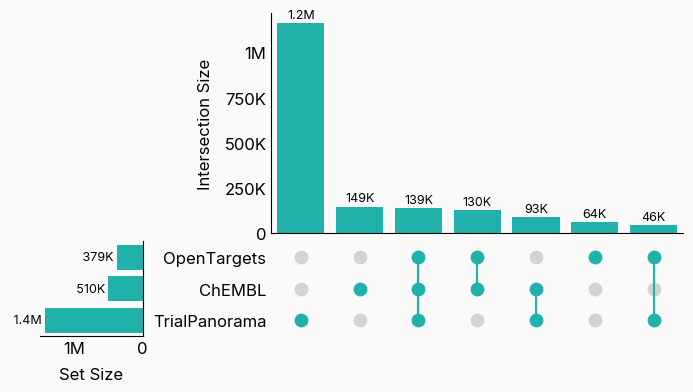

In [14]:
di_upset = make_upset_df(ct_all, "drug_indication_sources")
fig = plot_upset(di_upset, wspace=0.5)
savefig(fig, "d3_di_upset")

## 6. OpenTargets genetic evidence per subsource

Break down OpenTargets genetic evidence by datasource (subsource column)
and check risk ratios for I→Approved against OpenTargets clinical trials.

**Note:** This section requires raw Open Targets Platform 25.12 data
(`association_by_datasource_direct`, `association_overall_direct`, `target`)
downloaded to `data/sources/opentargets/25.12/`.
See [DATA_SOURCES.md](../DATA_SOURCES.md) for download instructions.

In [15]:
OT_DATA = DATA / "sources" / "opentargets" / "25.12"
OT_TARGET = OT_DATA / "target"

ct_ot = filter_ct_by(ct_all, "gene_drug_sources", "OpenTargets")
ct_ot = ct_ot.merge(
    filter_ct_by(ct_all, "drug_indication_sources", "OpenTargets")[["gene", "efo_id"]],
    on=["gene", "efo_id"],
)

# Load all datasource associations and map ENSG -> gene symbol
ot_by_ds = pd.read_parquet(
    OT_DATA / "association_by_datasource_direct",
    columns=["datasourceId", "targetId", "diseaseId", "score"],
)
ot_targets = pd.read_parquet(OT_TARGET, columns=["id", "approvedSymbol"])
ensg_to_symbol = dict(zip(ot_targets["id"], ot_targets["approvedSymbol"]))
ot_by_ds["gene"] = ot_by_ds["targetId"].map(ensg_to_symbol)
ot_by_ds["efo_id"] = ot_by_ds["diseaseId"].str.replace("_", ":")
ot_by_ds = ot_by_ds[ot_by_ds["gene"].notna()]

# Also load overall associations
ot_overall = pd.read_parquet(
    OT_DATA / "association_overall_direct",
    columns=["targetId", "diseaseId", "score"],
)
ot_overall["gene"] = ot_overall["targetId"].map(ensg_to_symbol)
ot_overall["efo_id"] = ot_overall["diseaseId"].str.replace("_", ":")
ot_overall = ot_overall[ot_overall["gene"].notna()]

# --- 6a: Per-datasource at multiple score thresholds (each source filtered by its own score) ---
subsource_threshold_results = []
for threshold in [0, 0.25, 0.5, 0.75]:
    filtered = ot_by_ds[ot_by_ds["score"] >= threshold] if threshold > 0 else ot_by_ds
    overall_filtered = ot_overall[ot_overall["score"] >= threshold] if threshold > 0 else ot_overall

    experiments = {}
    for ds in sorted(filtered["datasourceId"].unique()):
        subset = filtered.loc[filtered["datasourceId"] == ds, ["gene", "efo_id"]].drop_duplicates()
        experiments[ds] = (subset, ct_ot)
    experiments["overall"] = (overall_filtered[["gene", "efo_id"]].drop_duplicates(), ct_ot)

    results = run_multi(experiments, label_col="subsource")
    results["threshold"] = threshold
    subsource_threshold_results.append(results)

ot_subsource_results = pd.concat(subsource_threshold_results, ignore_index=True)
ot_subsource_results.to_csv(OUTPUT / "ot_subsource_comparison.csv", index=False)

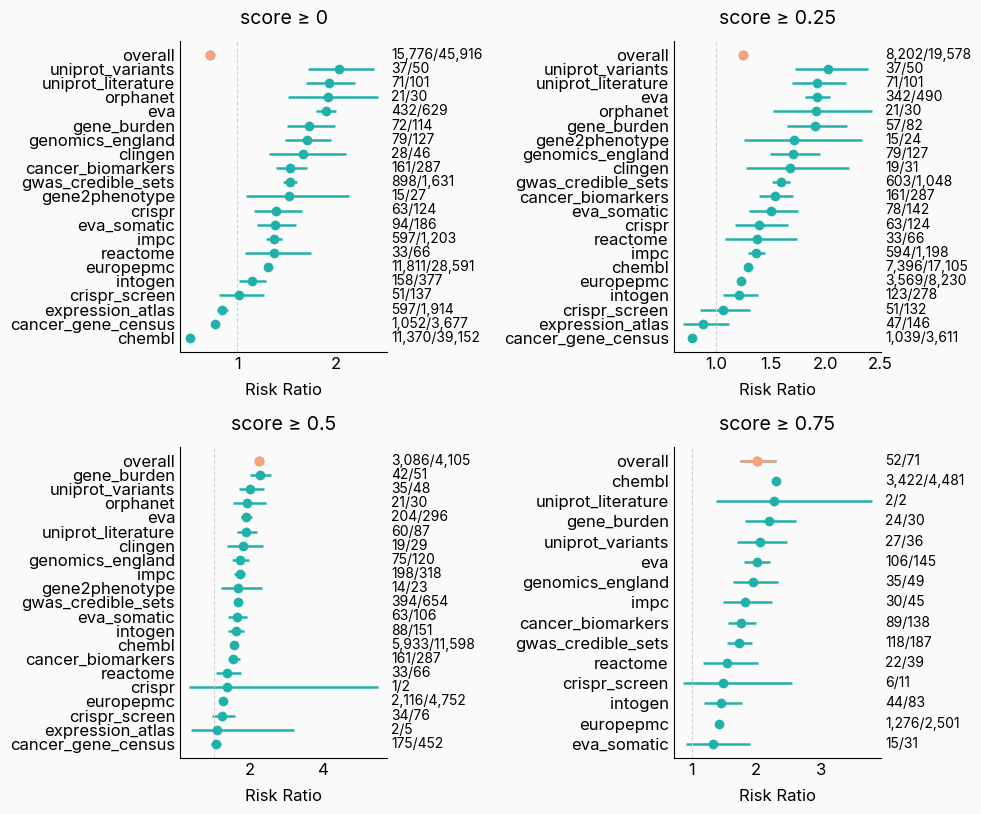

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8.3))
for ax, threshold in zip(axes.flatten(), [0, 0.25, 0.5, 0.75]):
    phase_df = ot_subsource_results[
        (ot_subsource_results["phase_label"] == "I→Approved")
        & (ot_subsource_results["threshold"] == threshold)
    ]
    # Drop empty results and sort by RR ascending, "overall" on top
    phase_df = phase_df[phase_df["n_yes"] > 0]
    phase_df = phase_df.sort_values("rr", ascending=True).reset_index(drop=True)
    non_overall = phase_df[phase_df["subsource"] != "overall"]
    overall_row = phase_df[phase_df["subsource"] == "overall"]
    phase_df = pd.concat([non_overall, overall_row], ignore_index=True)
    forest_plot(
        phase_df,
        "subsource",
        "I→Approved",
        title=f"score ≥ {threshold}",
        ax=ax,
        sort_order=phase_df["subsource"].tolist(),
    )
    # Highlight "overall" with second palette color
    labels = [t.get_text() for t in ax.get_yticklabels()]
    if "overall" in labels:
        c2 = plt.rcParams["axes.prop_cycle"].by_key()["color"][1]
        idx = labels.index("overall")
        row = overall_row.iloc[0]
        ax.errorbar(
            row["rr"],
            idx,
            xerr=[[row["rr"] - row["rr_ci_lower"]], [row["rr_ci_upper"] - row["rr"]]],
            fmt="o",
            color=c2,
            zorder=5,
        )
fig.tight_layout()
savefig(fig, "f_ot_subsources")

### 6b: Genetic-only OT datasources at different per-datasource score thresholds

In [17]:
GENETIC_DATASOURCES = {
    "gwas_credible_sets",
    "eva",
    "eva_somatic",
    "gene_burden",
    "genomics_england",
    "gene2phenotype",
    "clingen",
    "uniprot_variants",
    "uniprot_literature",
    "orphanet",
    "intogen",
}

ot_genetic = ot_by_ds[ot_by_ds["datasourceId"].isin(GENETIC_DATASOURCES)]

genetic_threshold_results = []
for threshold in [0.5, 0.65, 0.8]:
    # Max score across genetic datasources per pair, then filter
    agg = (
        ot_genetic.groupby(["gene", "efo_id"], as_index=False)["score"]
        .max()
        .query(f"score >= {threshold}")
    )
    ge_pairs = agg[["gene", "efo_id"]].drop_duplicates()
    result = validate(clinical_trials=ct_ot, targets=ge_pairs, **VALIDATE_KWARGS)
    result["threshold"] = threshold
    result["n_pairs"] = len(ge_pairs)
    genetic_threshold_results.append(result)

genetic_results = pd.concat(genetic_threshold_results, ignore_index=True)
genetic_results.to_csv(OUTPUT / "ot_genetic_threshold_comparison.csv", index=False)

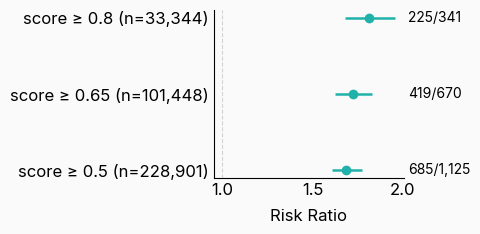

In [18]:
phase_df = genetic_results[genetic_results["phase_label"] == "I→Approved"]
fig, ax = plt.subplots(figsize=(5, 2.5))
forest_plot(
    phase_df.assign(
        label=lambda d: d["threshold"].map(
            lambda t: (
                f"score ≥ {t} (n={phase_df.loc[phase_df['threshold'] == t, 'n_pairs'].iloc[0]:,})"
            ),
        ),
    ),
    "label",
    "I→Approved",
    ax=ax,
)
fig.tight_layout()
savefig(fig, "g_ot_genetic_thresholds")